In [0]:
# Replace with your actual storage account name and key
# You learned how to generate storage account keys in the last lab
#removed keys and storage account cant be in github

In [0]:
curated_path = "abfss://curated@datalake60302085.dfs.core.windows.net/features_v1/"
curated_df = spark.read.parquet(curated_path)

In [0]:
curated_df.printSchema()
display(curated_df .limit(5))

root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)



asin,title,brand,price,reviewerID,overall,summary,reviewText,helpful,reviewTime,review_year
B006VFRIWQ,JVC 1.5-Megapixel 1080P High-Definition Everio Digital Video Camera (Blue) GZE200AUS,null,17.12,A13L8543HNHMH3,5.0,Great camera,I'm a daily vlogger on youtube (user name LupusLife) and use video cameras everyday. This camera has been a wonderful one to use. I would recommend getting a large memory card for it and the extended battery so you can record HD for over 4 hours in one stretch.. Great price also. It gets a big thumbs up from this youtuber.,"List(0, 0)","10 14, 2013",2013
B006VFRIWQ,JVC 1.5-Megapixel 1080P High-Definition Everio Digital Video Camera (Blue) GZE200AUS,null,17.12,A5M6G3QLLXBVF,5.0,THIS IS THE ONE!,"Small, packed with features, simple to use, and relatively inexpensive. This replaced a costly, larger, and complicated camcorder that my wife was never comfortable using -- and she loves it . . .","List(11, 13)","03 7, 2013",2013
B006VFRIWQ,JVC 1.5-Megapixel 1080P High-Definition Everio Digital Video Camera (Blue) GZE200AUS,null,17.12,A1F1DD3UJ7603B,4.0,JVC Camera a Great Buy,"I love the HD quality of this camera. The camera doesn't have a lot of features, but the Optical zoom is great and it supports a 64 G memory card. The fast lens is great; just wish it supported filters. The LCD screen is difficult to use outdoors in direct sunlight, and ergonomics of the start/stop button aren't the best. It is fine when used with a tripod, and hand held is OK at low zooms. I like the HDMI output. I'd give this camera a 4 out of 5 rating. I don't need lots of features since I do my editing on the computer.","List(0, 0)","08 27, 2013",2013
B006VFRIWQ,JVC 1.5-Megapixel 1080P High-Definition Everio Digital Video Camera (Blue) GZE200AUS,null,17.12,A28UZUHG2U88GW,5.0,Love it,I love this camera full hd and great zoom. The only thing i hate about it is that it takes for ever to process a video once its uploaded to the computer. Idk if theres a software that can make this faster but i sure do hate waiting a couple of hours for it to process. But other wise the quality is awesome.,"List(4, 5)","04 14, 2013",2013
B006VFRIWQ,JVC 1.5-Megapixel 1080P High-Definition Everio Digital Video Camera (Blue) GZE200AUS,null,17.12,A7M7JDSCN0HMM,4.0,"For what it is, 4 stars but has a significant flaw when it comes to getting videos off","It's small and light. Seems well made and shoots good video. One thing you should be aware of is that it's not easy to just pop the SD card into your computer and copy the movies to your hard drive. They are all in AVCHD format...and buried deep in multiple ambiguously named folders. This means you end up with large files in a specific, less common format.If you choose to use the JVC bundled software, it's slightly easier to access the files. For me, I'd just like to unload the video files myself.So... copying the files off is not impossible but it's not as easy as it is on your point-and-shoot camera. Also keep in mind that the files are various levels of HD.For about $150, you'll be happy. At that price point, it's a reasonable purchase.Battery life...not so good.","List(1, 1)","08 21, 2013",2013


In [0]:
print("Rows:", curated_df.count())
print("Columns:", len(curated_df.columns))

Rows: 10124562
Columns: 11


In [0]:
#check for missing values
from pyspark.sql.functions import col

curated_df.select(
    col("reviewText").isNull().alias("reviewText_null"),
    col("overall").isNull().alias("overall_null")
).groupBy("reviewText_null", "overall_null").count().show()

+---------------+------------+--------+
|reviewText_null|overall_null|   count|
+---------------+------------+--------+
|          false|       false|10124562|
+---------------+------------+--------+



In [0]:
#check empty reviwes
from pyspark.sql.functions import length

curated_df.filter(length(col("reviewText")) == 0).count()

0

In [0]:
#convert to pandas for visualization
rating_dist = curated_df.groupBy("overall").count().orderBy("overall").toPandas()

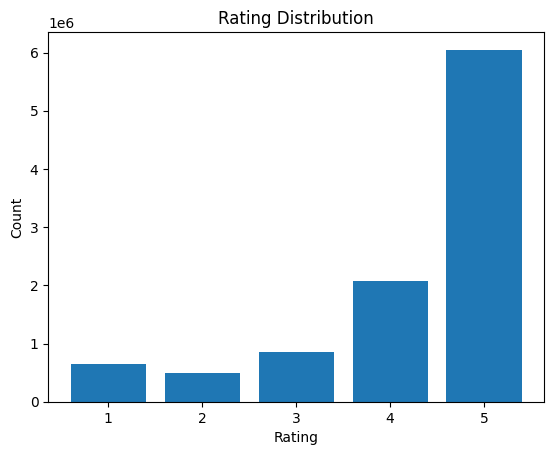

In [0]:
#rating distribution
import matplotlib.pyplot as plt

plt.figure()
plt.bar(rating_dist["overall"], rating_dist["count"])
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.show()

'''
The rating distribution shows that most reviews are 4 or 5 stars, with 5-star reviews being the majority. Lower ratings (1–3 stars) appear much less frequently. This indicates that the dataset is imbalanced toward positive reviews. This matters for feature engineering because imbalanced data can influence how models learn patterns, especially when building features related to sentiment or rating prediction.
'''

In [0]:
#create a length column
from pyspark.sql.functions import length

df_length = curated_df.withColumn("review_length", length("reviewText"))

In [0]:
#convert a smaple to pandas
length_sample = df_length.select("review_length").sample(fraction=0.01, seed=42).toPandas()

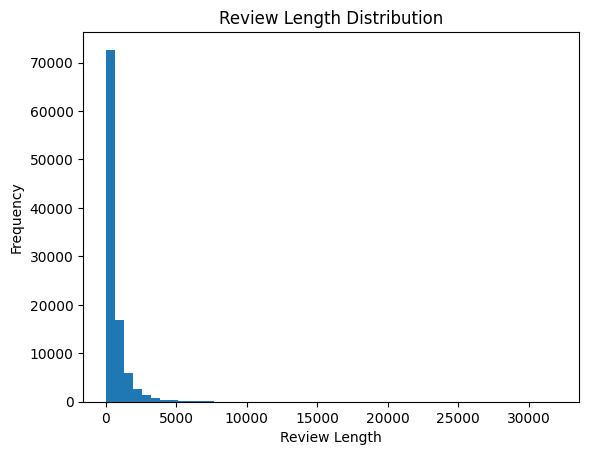

In [0]:
#plot length distribution
plt.figure()
plt.hist(length_sample["review_length"], bins=50)
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Review Length Distribution")
plt.show()

"""
The review length distribution shows that most reviews are relatively short, while a small number of reviews are extremely long. The distribution is right-skewed, meaning there is a long tail of very long reviews. This matters for feature engineering because text-based features like TF-IDF and embeddings are affected by text length. Short reviews may contain limited information, while longer reviews may provide richer textual signals.
"""

In [0]:
#We should NOT just randomly sample everything.
#We should sample from each year, so older and newer reviews are both included.

In [0]:
curated_df.groupBy("review_year").count().orderBy("review_year").show()

+-----------+-------+
|review_year|  count|
+-----------+-------+
|       1999|    432|
|       2000|   4902|
|       2001|   9654|
|       2002|  13890|
|       2003|  21282|
|       2004|  30954|
|       2005|  57828|
|       2006|  92682|
|       2007| 215760|
|       2008| 298998|
|       2009| 423672|
|       2010| 621882|
|       2011|1039098|
|       2012|1696374|
|       2013|3554952|
|       2014|2042202|
+-----------+-------+



In [0]:
total_rows = curated_df.count()
target_sample = 300000

fractions = {}

year_counts = curated_df.groupBy("review_year").count().collect()

for row in year_counts:
    year = row["review_year"]
    count = row["count"]
    fractions[year] = (count / total_rows) * (target_sample / count)

df_sampled = curated_df.sampleBy("review_year", fractions=fractions, seed=42)

In [0]:
print("Sample rows:", df_sampled.count())
# A stratified sampling approach based on review_year was used to reduce the impact of temporal drift. 
# This ensures that reviews from different years are proportionally represented in the sampled dataset, preserving variations in language over time.

Sample rows: 300168


In [0]:
df_sampled.printSchema()

root
 |-- asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- reviewerID: string (nullable = true)
 |-- overall: double (nullable = true)
 |-- summary: string (nullable = true)
 |-- reviewText: string (nullable = true)
 |-- helpful: array (nullable = true)
 |    |-- element: integer (containsNull = true)
 |-- reviewTime: string (nullable = true)
 |-- review_year: integer (nullable = true)



In [0]:
# Compare rating distribution with original dataset
curated_df.groupBy("overall").count().orderBy("overall").show()
df_sampled.groupBy("overall").count().orderBy("overall").show()

+-------+-------+
|overall|  count|
+-------+-------+
|    1.0| 651672|
|    2.0| 492336|
|    3.0| 852636|
|    4.0|2080158|
|    5.0|6047760|
+-------+-------+

+-------+------+
|overall| count|
+-------+------+
|    1.0| 19367|
|    2.0| 14617|
|    3.0| 25223|
|    4.0| 61894|
|    5.0|179067|
+-------+------+



In [0]:
print("Rows:", df_sampled.count())
print("Columns:", len(df_sampled.columns))

Rows: 300168
Columns: 11


In [0]:
#storage_account_name = "datalake60302085"
#sampled_gold_path = (
#f"abfss://curated@{storage_account_name}.dfs.core.windows.net/"
#"features_v1_sampled/"
#)
df_sampled.write \
.mode("overwrite") \
.parquet(sampled_gold_path)